# Customer Intelligence System

## Executive Summary
This project develops a Customer Intelligence System for a telecommunications company to address two key business challenges: predicting customer churn and understanding customer segments.

A supervised machine learning model was built to estimate churn risk, while unsupervised clustering was used to identify meaningful customer groups based on behavior, spending patterns, and service usage.

The final system provides:

- Probability of churn for each customer

- Risk classification to support retention strategies

- Segment assignment to guide targeted business actions

The model achieves strong predictive performance with high recall for churners, ensuring that most at-risk customers are identified early. Combined with segmentation insights, the system enables data-driven decision making for marketing, pricing, and customer retention initiatives.

## 1. Business Problem
The company wants to reduce customer churn and better understand customer segments. 
Churn leads to revenue loss. We aim to identify high-risk customers and group customers based on behavior.

## 2. ML Formulation
A) Churn Prediction → Binary Classification  
B) Customer Segmentation → Clustering

### Methodology Overview

The project follows a structured machine learning workflow aligned with real-world production practices:

**1. Data Understanding & Cleaning**\
Missing values were handled, irrelevant features were removed, and categorical variables were standardized.

**2. Exploratory Data Analysis (EDA)**\
Relationships between features and churn were analyzed using visualizations to identify potential predictors.

**3. Feature Engineering**\
Transformations were applied to better capture nonlinear relationships, particularly for tenure.

**4. Model Development**\
Multiple classification algorithms were evaluated using pipelines to prevent data leakage.

**5. Threshold Optimization**\
The decision threshold was tuned to prioritize recall, aligning with business requirements.

**6. Model Selection & Evaluation**\
Models were compared using ROC-AUC and class-specific metrics.

**7. Customer Segmentation**\
K-Means clustering was applied to identify distinct customer groups.

## 3. Target Variable
Churn Value(1/0)

## 4. Success Metrics
Since churn prediction is a business-critical problem where false negatives (missed churners) are costly, our evaluation strategy will be:

- **Primary Business Metric:** Maximize Recall for Churn (Class 1) while maintaining acceptable precision.

- **Model Quality Metric:** Use ROC-AUC to evaluate the model’s ability to rank churners higher than non-churners independent of threshold.

- **Balanced Metric:** Monitor F1 Score to ensure that precision does not degrade excessively while improving recall.

- **Operational Strategy:** Tune classification threshold to optimize recall based on business tolerance for false positives.

## 5. Final Output
Churn probability + Risk level + Segment label

---

# About Dataset
## Context
A fictional telco company that provided home phone and Internet services to 7043 customers in California in Q3.

## Data Description
7043 observations with 33 variables

**CustomerID**: A unique ID that identifies each customer.

**Count**: A value used in reporting/dashboarding to sum up the number of customers in a filtered set.

**Country**: The country of the customer’s primary residence.

**State**: The state of the customer’s primary residence.

**City**: The city of the customer’s primary residence.

**Zip Code**: The zip code of the customer’s primary residence.

**Lat Long**: The combined latitude and longitude of the customer’s primary residence.

**Latitude**: The latitude of the customer’s primary residence.

**Longitude**: The longitude of the customer’s primary residence.

**Gender**: The customer’s gender: Male, Female

**Senior Citizen**: Indicates if the customer is 65 or older: Yes, No

**Partner**: Indicate if the customer has a partner: Yes, No

**Dependents**: Indicates if the customer lives with any dependents: Yes, No. Dependents could be children, parents, grandparents, etc.

**Tenure Months**: Indicates the total amount of months that the customer has been with the company by the end of the quarter specified above.

**Phone Service**: Indicates if the customer subscribes to home phone service with the company: Yes, No

**Multiple Lines**: Indicates if the customer subscribes to multiple telephone lines with the company: Yes, No

**Internet Service**: Indicates if the customer subscribes to Internet service with the company: No, DSL, Fiber Optic, Cable.

**Online Security**: Indicates if the customer subscribes to an additional online security service provided by the company: Yes, No

**Online Backup**: Indicates if the customer subscribes to an additional online backup service provided by the company: Yes, No

**Device Protection**: Indicates if the customer subscribes to an additional device protection plan for their Internet equipment provided by the company: Yes, No

**Tech Support**: Indicates if the customer subscribes to an additional technical support plan from the company with reduced wait times: Yes, No

**Streaming TV**: Indicates if the customer uses their Internet service to stream television programing from a third party provider: Yes, No. The company does not charge an additional fee for this service.

**Streaming Movies**: Indicates if the customer uses their Internet service to stream movies from a third party provider: Yes, No. The company does not charge an additional fee for this service.

**Contract**: Indicates the customer’s current contract type: Month-to-Month, One Year, Two Year.

**Paperless Billing**: Indicates if the customer has chosen paperless billing: Yes, No

**Payment Method**: Indicates how the customer pays their bill: Bank Withdrawal, Credit Card, Mailed Check

**Monthly Charge**: Indicates the customer’s current total monthly charge for all their services from the company.

**Total Charges**: Indicates the customer’s total charges, calculated to the end of the quarter specified above.

**Churn Label**: Yes = the customer left the company this quarter. No = the customer remained with the company. Directly related to Churn Value.

**Churn Value**: 1 = the customer left the company this quarter. 0 = the customer remained with the company. Directly related to Churn Label.

**Churn Score**: A value from 0-100 that is calculated using the predictive tool IBM SPSS Modeler. The model incorporates multiple factors known to cause churn. The higher the score, the more likely the customer will churn.

**CLTV**: Customer Lifetime Value. A predicted CLTV is calculated using corporate formulas and existing data. The higher the value, the more valuable the customer. High value customers should be monitored for churn.

**Churn Reason**: A customer’s specific reason for leaving the company. Directly related to Churn Category.

---

# Importing Libraries

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_fscore_support, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# 1. Data Acquisition

In [10]:
df = pd.read_excel('../data/Telco_customer_churn.xlsx')
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [11]:
# Assistant
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline  

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

`Total Charges` should be of type float so we will change it

In [13]:
df[df['Total Charges'] == ' '].count()

CustomerID           11
Count                11
Country              11
State                11
City                 11
Zip Code             11
Lat Long             11
Latitude             11
Longitude            11
Gender               11
Senior Citizen       11
Partner              11
Dependents           11
Tenure Months        11
Phone Service        11
Multiple Lines       11
Internet Service     11
Online Security      11
Online Backup        11
Device Protection    11
Tech Support         11
Streaming TV         11
Streaming Movies     11
Contract             11
Paperless Billing    11
Payment Method       11
Monthly Charges      11
Total Charges        11
Churn Label          11
Churn Value          11
Churn Score          11
CLTV                 11
Churn Reason          0
dtype: int64

We see that we have missing values in the `Total Charges` column

In [14]:
df = df.replace({'Total Charges': {' ': np.nan}})
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'] = df['Total Charges'].fillna(df['Total Charges'].mean())

In [15]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,2283.300441,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,2265.000258,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,18.800000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,402.225000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,1400.550000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,3786.600000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


We see that the only feature with missing values is the `Churn Reason`

In [16]:
df.describe(include=['object'])

C:\Users\alina\AppData\Local\Temp\ipykernel_36264\3011300674.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=['object'])


,CustomerID,Country,State,City,Lat Long,Gender,Senior Citizen,Partner,Dependents,Phone Service,...,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Churn Label,Churn Reason
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043,7043,1869
unique,7043,1,1,1129,1652,2,2,2,2,2,...,3,3,3,3,3,3,2,4,2,20
top,3668-QPYBK,United States,California,Los Angeles,"33.964131, -118.272783",Male,No,No,No,Yes,...,No,No,No,No,No,Month-to-month,Yes,Electronic check,No,Attitude of support person
freq,1,7043,7043,305,5,3555,5901,3641,5416,6361,...,3088,3095,3473,2810,2785,3875,4171,2365,5174,192


### Target Distribution

In [17]:
counts = df['Churn Value'].value_counts()

total = counts[0] + counts[1]
percentage_0 = (counts[0] / total)*100
percentage_1 = (counts[1] / total)*100

print(f"Percentage of Records with Churn Value 0: {np.round(percentage_0, 2)}%")
print(f"Percentage of Records with Churn Value 1: {np.round(percentage_1, 2)}%")

Percentage of Records with Churn Value 0: 73.46%
Percentage of Records with Churn Value 1: 26.54%


We see that we have only 26.54% of the records indicating customers that churned. Making this dataset imbalanced.

---

# 2. EDA

First off we remove some features that will not provide us any value if we keep them, like `CustomerID`, and `Count`. And we also remove features that will only mean something if a cutomer churns, and have no value for us beforehand. These are `Churn Label`, `Churn Score`, `Churn Reason`, and `CLTV`. We will also drop the `Lat Long` column as we already have the value of it as separate columns. We also see that `Country` and `State` have only one value, so we don't need them either. We drop `City` as well as it is a very high cardinality feature. We also remove `Zip code`, as that is also a high cardinality feature. We drop `Latitude` and `Longitude` as well, as by themselves they provide no vlaue to us, we may include them when we do clustering

In [18]:
new_df = df.drop(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Churn Label', 'Churn Score', 'Churn Reason', 'CLTV'], axis=1)

In [19]:
new_df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1


Now let us check for null values in our dataset

In [20]:
new_df.isnull().sum()

Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Value          0
dtype: int64

In [21]:
new_df.duplicated().sum()

np.int64(22)

In [22]:
new_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   str    
 1   Senior Citizen     7043 non-null   str    
 2   Partner            7043 non-null   str    
 3   Dependents         7043 non-null   str    
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   str    
 6   Multiple Lines     7043 non-null   str    
 7   Internet Service   7043 non-null   str    
 8   Online Security    7043 non-null   str    
 9   Online Backup      7043 non-null   str    
 10  Device Protection  7043 non-null   str    
 11  Tech Support       7043 non-null   str    
 12  Streaming TV       7043 non-null   str    
 13  Streaming Movies   7043 non-null   str    
 14  Contract           7043 non-null   str    
 15  Paperless Billing  7043 non-null   str    
 16  Payment Method     7043 non-null   

We replace the null value with the mean of the column

## Correlation Analysis

In [23]:
new_df.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value'],
      dtype='str')

So save time, let us first plot the categorical features against our categorical target

In [24]:
for column in new_df.columns:
    print(f"Unique values in {column}: {new_df[column].unique()}")

Unique values in Gender: <StringArray>
['Male', 'Female']
Length: 2, dtype: str
Unique values in Senior Citizen: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Unique values in Partner: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Unique values in Dependents: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Unique values in Tenure Months: [ 2  8 28 49 10  1 47 17  5 34 11 15 18  9  7 12 25 68 55 37  3 27 20  4
 58 53 13  6 19 59 16 52 24 32 38 54 43 63 21 69 22 61 60 48 40 23 39 35
 56 65 33 30 45 46 62 70 50 44 71 26 14 41 66 64 29 42 67 51 31 57 36 72
  0]
Unique values in Phone Service: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Unique values in Multiple Lines: <StringArray>
['No', 'Yes', 'No phone service']
Length: 3, dtype: str
Unique values in Internet Service: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
Unique values in Online Security: <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
Unique values in Online Backup: <S

For our categorical features, we see that we have values `Yes`, `No`, `No internet service`, and `No phone service`. We will map these to Yes and No only, `1 for Yes`, and `0 for No, No internet service, No phone service`

In [25]:
for column in new_df.columns:
    unique_vals = set(new_df[column].dropna().unique())
    if unique_vals.issubset({'Yes', 'No', 'No internet service', 'No phone service'}):
        # Fix: Apply replace directly to the column, not the entire dataframe
        new_df[column] = new_df[column].replace({
            'No internet service': 'No',
            'No phone service': 'No'
        })

In [26]:
new_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   str    
 1   Senior Citizen     7043 non-null   str    
 2   Partner            7043 non-null   str    
 3   Dependents         7043 non-null   str    
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   str    
 6   Multiple Lines     7043 non-null   str    
 7   Internet Service   7043 non-null   str    
 8   Online Security    7043 non-null   str    
 9   Online Backup      7043 non-null   str    
 10  Device Protection  7043 non-null   str    
 11  Tech Support       7043 non-null   str    
 12  Streaming TV       7043 non-null   str    
 13  Streaming Movies   7043 non-null   str    
 14  Contract           7043 non-null   str    
 15  Paperless Billing  7043 non-null   str    
 16  Payment Method     7043 non-null   

We have successfully replaced all extra values from Yes/No categoricals

#### Visualization of Categoricals

First for the features that we just converted, let us plot them against the target to find out relationships between them

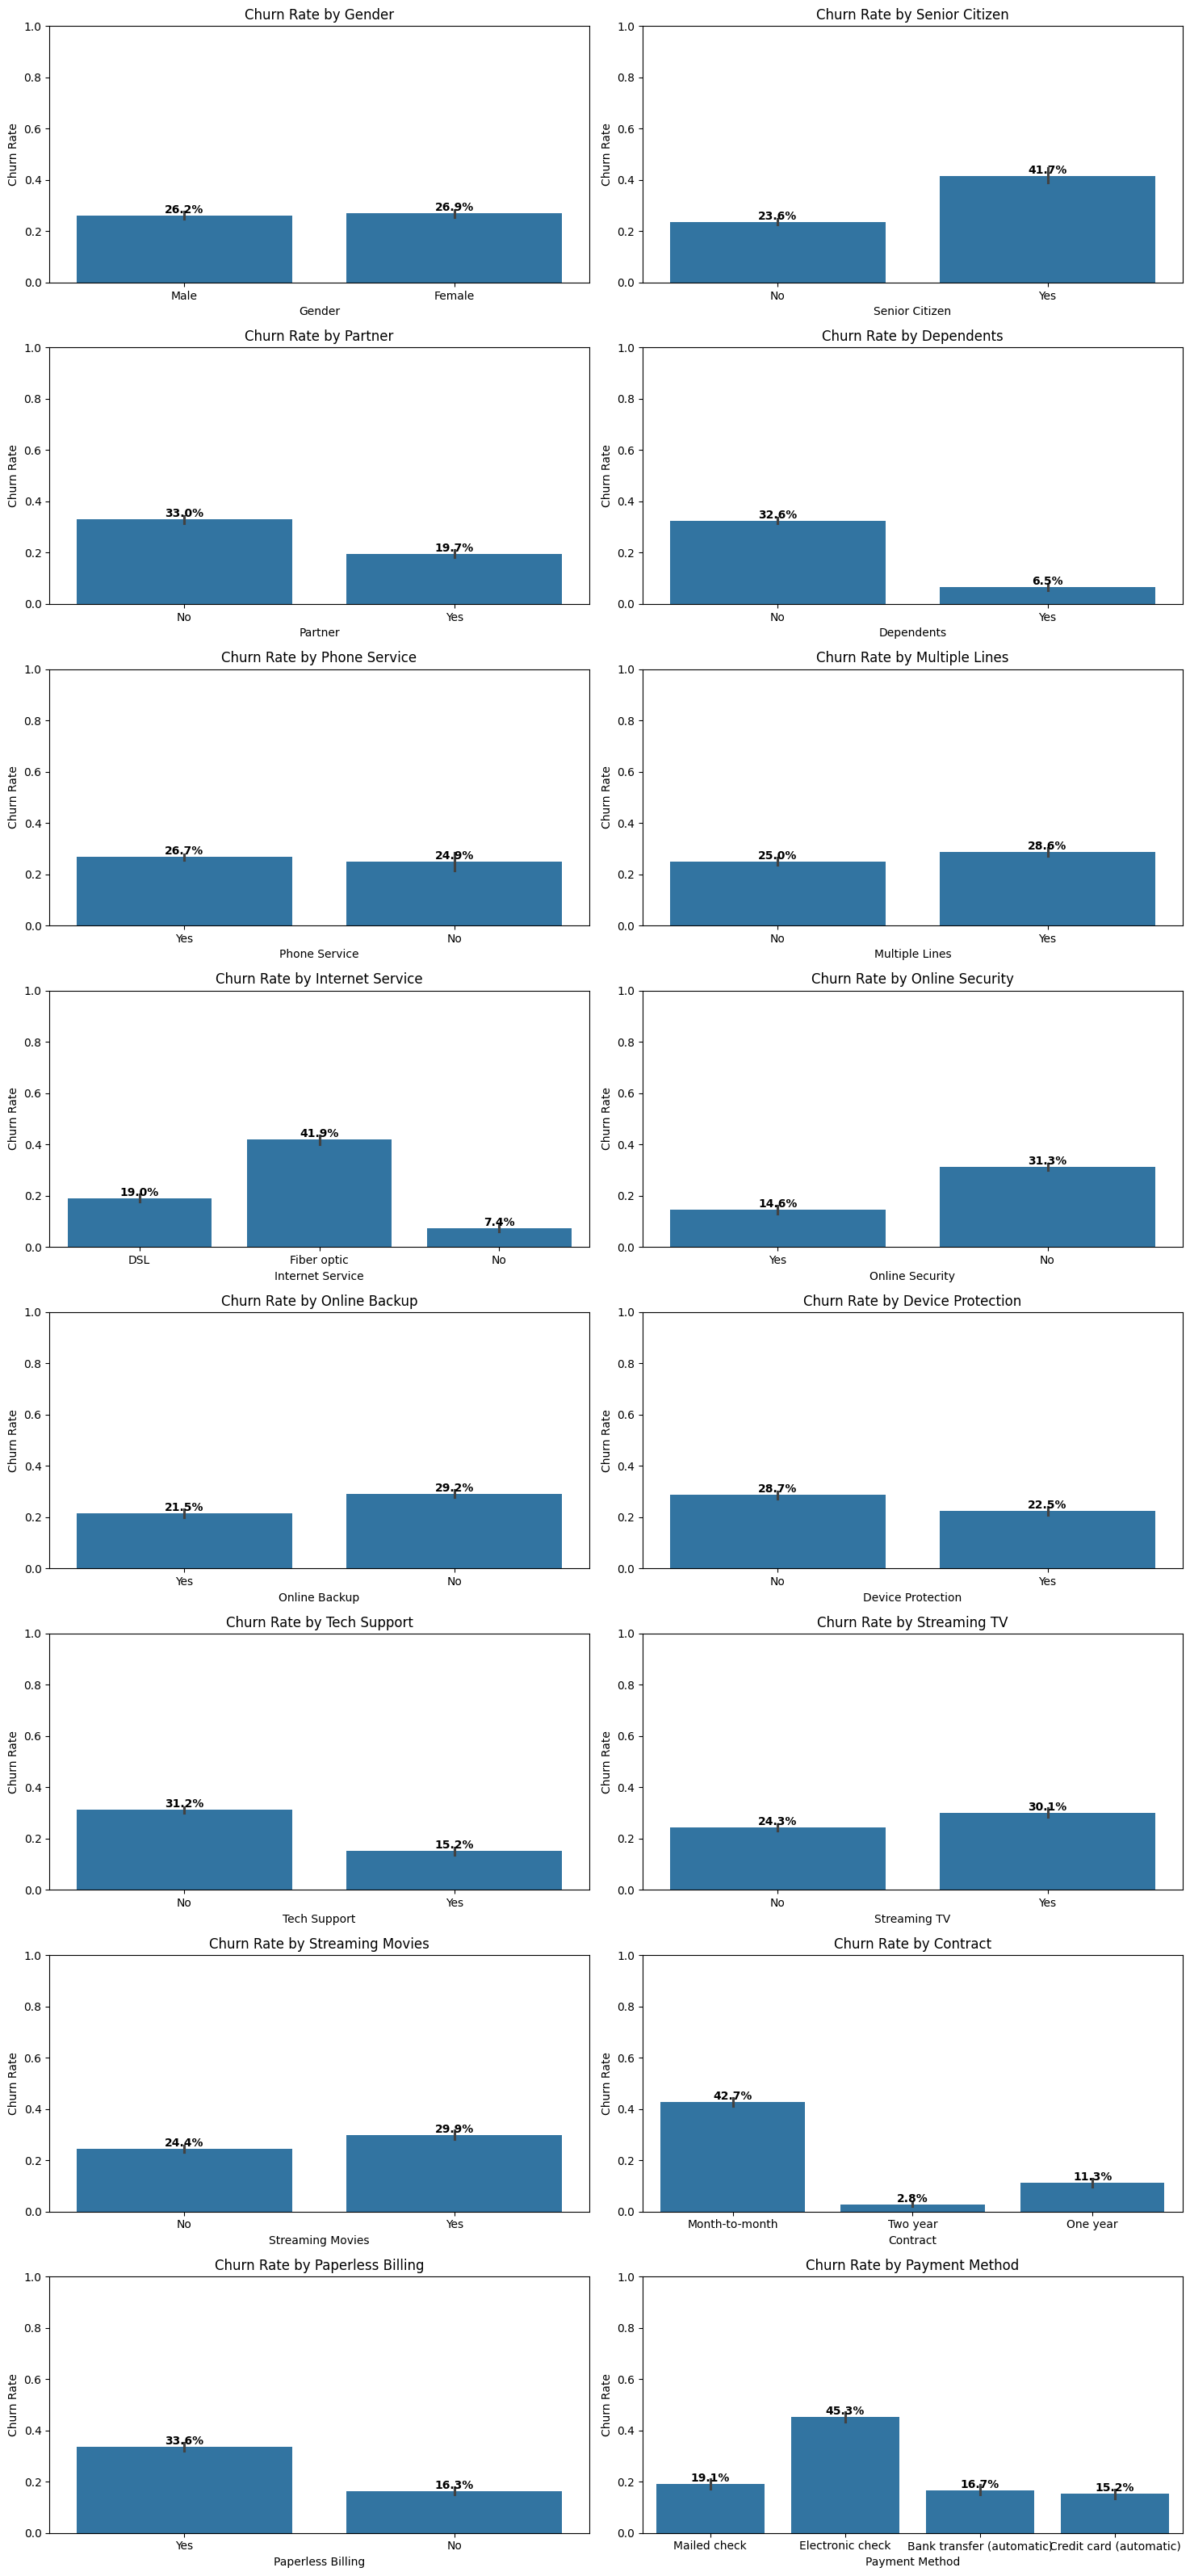

In [27]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

# Exclude high-cardinality columns
exclude_cols = ['CustomerID', 'Count', 'City', 'Zip Code', 'Latitude', 'Longitude']

features_to_plot = [
    col for col in new_df.columns 
    if col not in exclude_cols 
    and col != 'Churn Value'
    and new_df[col].nunique() <= 5   # low-cardinality only
]

cols = 2
rows = math.ceil(len(features_to_plot) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    ax = axes[i]
    
    sns.barplot(
        data=new_df,
        x=feature,
        y='Churn Value',   # mean = churn rate
        ax=ax
    )
    
    ax.set_title(f'Churn Rate by {feature}')
    ax.set_ylabel('Churn Rate')
    ax.set_ylim(0, 1)

    # 🔹 Add churn rate labels
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height*100:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=10,
                    fontweight='bold')

# Remove extra empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- Gender: The churn rate for females (26.9%) and males (26.2%) is nearly identical, indicating that gender has no meaningful relationship with churn behavior in this dataset.

- Senior Citizen: Senior citizens exhibit a churn rate of 41.7%, compared to 23.6% for non-senior customers. This substantial difference suggests that senior status is a strong predictor of churn. Age-related factors such as pricing sensitivity, service expectations, or usage patterns may influence this behavior.

- Partner: Customers without a partner have a churn rate of 33%, compared to 19.7% for those with a partner. This significant separation indicates that partnership status is a strong predictor of churn. Customers in shared households may have more stable service needs, reducing churn likelihood.

- Dependents: Customers without dependents show a significantly higher churn rate (32.6%) compared to customers with dependents (6.5%). This suggests that household responsibility and multi-user dependency may contribute to lower churn rates.

- Phone Service: The churn rate difference between customers with phone service (26.7%) and those without (24.9%) is minimal. Given the small separation and the fact that most customers have phone service, this feature appears to have weak predictive power.

- Multiple Lines: Customers with multiple lines have a churn rate of 28.6% compared to 25% for those without. The difference is modest, indicating that this feature may provide limited predictive value on its own.

- Internet Service: We see that customers using Fiber optics have the highest churn rate (41.9%) compared to DSL (19%), and those with no internet sevice (7.4%). This is a strong predictor of churn. Possible explanations could be price sensitivity as Fiber optics usually costs more, or it could be higher service expectations, that may not be met.

- Online Security: Customers without online security exhibit a churn rate of 31.3%, compared to 14.6% for those who have it. This large separation makes online security a strong predictor of churn. The presence of additional services may increase customer stickiness.

- Online Backup: Customers without online backup have a churn rate of 29.2%, compared to 21.5% for those with backup services. This moderate difference suggests that bundled service adoption may reduce churn probability.

- Device Protection: Customers without device protection show higher churn rates compared to those who have it, of 28.7% compared to 22.5% of those who have it. This suggests additional service engagement may correlate with retention.

- Tech Support: Customers without tech support display significantly higher churn rates (31.2%) compared to those with support services (15.2%). This is likely a strong predictor, as access to support may improve customer satisfaction and retention.

- Streaming TV / Streaming Movies: Customers who use streaming services show moderately higher churn rates (~5–6% difference). This suggests a moderate association. These customers may represent higher-usage segments that are more sensitive to service performance or pricing.

- Contract: We see that Month-to-Month contract has the highest churn rate (42.7%), as compared to One year (11.3%), and Two year (2.8%). This is a strong predictor of churn. This suggests price sensitivity to Monthly charges

- Paperless Billing: Customers using paperless billing exhibit higher churn rates (33.6%) compared to those using traditional billing methods (16.3%). This represents a moderate predictive signal and may reflect differences in customer engagement or payment behavior.

- Payment Method: Customers using Electronic check for payment, have the highest churn rate (45.3%) compared to Mailed check (19.1%), Bank transfer (automatic) (16.7%), and Credit card (automatic) (15.2%), making it a strong predictor of churn. One possible explanation is that customers using automatic payment methods (credit card or bank transfer) may demonstrate higher commitment or lower friction in billing, whereas electronic check users may represent less stable or more price-sensitive segments.

#### Numeric features analysis

In [28]:
numeric_features = new_df.select_dtypes(['int', 'float']).columns.tolist()
numeric_features = [col for col in numeric_features if new_df[col].nunique() > 2]
numeric_features

['Tenure Months', 'Monthly Charges', 'Total Charges']

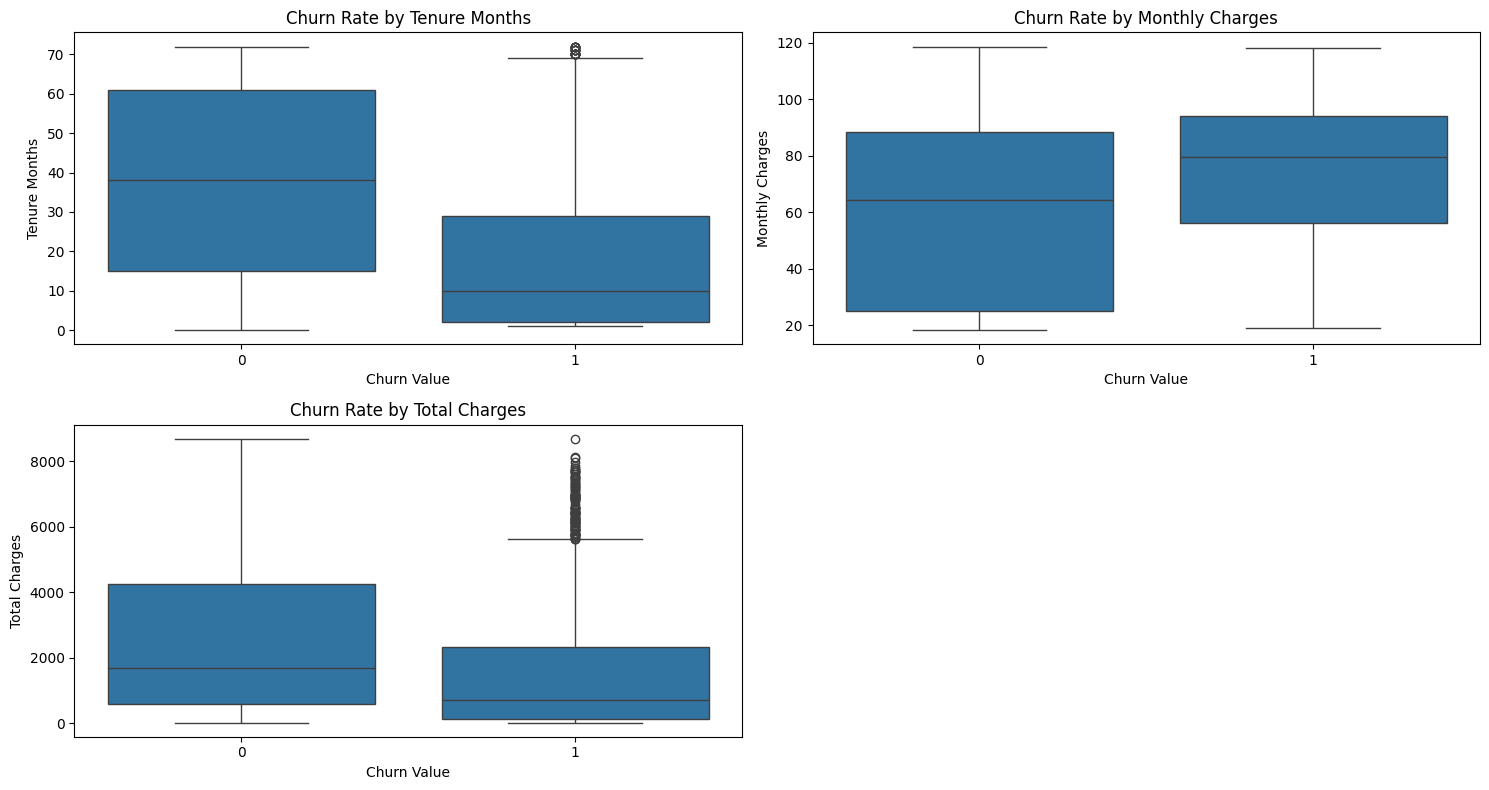

In [29]:
cols = 2
rows = math.ceil(len(numeric_features) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    ax = axes[i]
    
    sns.boxplot(
        data=new_df,
        x='Churn Value',   # mean = churn rate
        y=feature,
        ax=ax
    )
    
    ax.set_title(f'Churn Rate by {feature}')
    ax.set_ylabel(feature)

# Remove extra empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Insights for Numeric Features:

- Tenure Months: We see that Customers with higher Tenure Months have a lower churn rate, the clear separation between those who churn and those who don't makes it a strong predictor. This could be be because trust establishment after staying with a company for long periods

- Monthly Charges: We see the Customers with higher Monthly Charges, have a higher churn rate, the separation between the median is a give away of this relation, though this is a moderate predictor. This could be because of price sensistivity

- Total Charges: We see that Customers with higher Total Charges. We need to see that Total Charges itself is not an independent feature, as it depends upon Monthly Charges, and Tenure Months, likely calculated through `Total Charges = Monthly Charges * Tenure Months`. This will lead to multicollinearity later.

In [30]:
new_df = new_df.drop('Total Charges', axis=1)

In [31]:
new_df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Churn Value
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,1


# 3. Model Building

First, we will separate features and target

In [32]:
X = new_df.drop(['Churn Value'], axis=1)
y = new_df['Churn Value']

Now we will separate numeric and categorical features

In [33]:
categorical_features = X.select_dtypes(['object']).columns.tolist()
numeric_features = X.select_dtypes(['int', 'float']).columns.tolist()

C:\Users\alina\AppData\Local\Temp\ipykernel_36264\1511727653.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(['object']).columns.tolist()


Creating a preprocessing pipeline

In [34]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ]
)

Now we will split training and testing data

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42, test_size=0.2)

#### Training a Baseline Model

In [36]:

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression())
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_train)

In [37]:
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      4139
           1       0.67      0.58      0.62      1495

    accuracy                           0.81      5634
   macro avg       0.76      0.74      0.75      5634
weighted avg       0.81      0.81      0.81      5634



In [38]:
y_pred = pipe.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



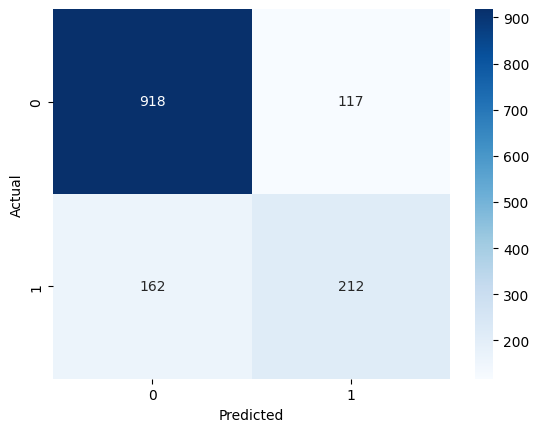

In [39]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues') # 'd' avoids scientific notation
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [40]:
y_probs = pipe.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_probs)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8467565682399442


Let us try balancing the weights and tuning the thresholds for classification

In [41]:
pipe = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(class_weight='balanced'))
    ]
)

We will first create a validation split, from the training set

In [42]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, stratify=y_train, test_size=0.25, random_state=42)

In [43]:
pipe.fit(X_tr, y_tr)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [44]:
y_probs = pipe.predict_proba(X_val)[:, 1]
thresholds = np.linspace(0.05, 0.95, 19)

best = None
for t in thresholds:
    y_pred = (y_probs >= t).astype(int)
    precision, recall, f1_score, _ = precision_recall_fscore_support(y_val, y_pred, average='binary', zero_division=0)

    if precision >= 0.40:
        if best is None or recall > best['recall']:
             best = {"threshold": t, "precision": precision, "recall": recall, "f1": f1_score}

best

{'threshold': np.float64(0.25),
 'precision': 0.41383495145631066,
 'recall': 0.9117647058823529,
 'f1': 0.5692821368948247}

We found the best threshold, now we will use it on the test set

In [45]:
pipe.fit(X_train, y_train)
y_test_probs = pipe.predict_proba(X_test)[:, 1]

y_test_pred = (y_test_probs >= best['threshold']).astype(int)
print("Chosen threshold:", best["threshold"])
print(classification_report(y_test, y_test_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_test_probs))

Chosen threshold: 0.25
              precision    recall  f1-score   support

           0       0.96      0.54      0.69      1035
           1       0.42      0.94      0.58       374

    accuracy                           0.65      1409
   macro avg       0.69      0.74      0.64      1409
weighted avg       0.82      0.65      0.66      1409

Test ROC-AUC: 0.8467436513472318


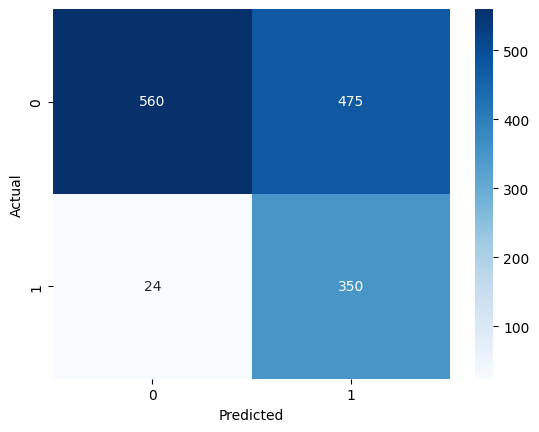

In [46]:
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues') # 'd' avoids scientific notation
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

After balancing the weights, and lowering the classification threshold, we see that our Recall has improved significantly and we are able to find more churners, but as a trade-off we see that our false positive have increased and precision has taken a hit

## Feature Engineering

Now let us explore our features further and try to find new features that could help us improve our model

In [47]:
X.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges'],
      dtype='str')

Before moving forward, let us create a function that will handle our entire modeling process, so that we don't have rebuild our preprocessor and base pipe again and again manually

In [48]:
def run_model_experiment(df, target_col='Churn Value', model=LogisticRegression, drop_cols=None, class_weight=None):
    if drop_cols is None:
        drop_cols = []

    X = df.drop(columns=[target_col] + drop_cols)
    y = df[target_col]

    categorical_features = X.select_dtypes(['object']).columns.tolist()
    numeric_features = X.select_dtypes (['int', 'float']).columns.tolist()

    binary_numeric_features = [col for col in numeric_features if X[col].nunique() == 2]
    continuous_numeric_features = [col for col in numeric_features if col not in binary_numeric_features]

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), continuous_numeric_features),
            ('bin', 'passthrough', binary_numeric_features),
            ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
        ]
    )

    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)

    if model == XGBClassifier:
        model_instance = model()
    elif class_weight is not None:
        model_instance = model(class_weight=class_weight)
    else:
        model_instance = model()
    
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model_instance)
    ])

    pipe.fit(X_train, y_train)

    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)

    y_train_probs = pipe.predict_proba(X_train)[:, 1]
    y_test_probs = pipe.predict_proba(X_test)[:, 1]

    return {
        'pipe': pipe,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'y_train_pred': y_train_pred,
        'y_test_pred': y_test_pred,
        'y_train_probs': y_train_probs,
        'y_test_probs': y_test_probs,
        'train_report': classification_report(y_train, y_train_pred),
        'test_report': classification_report(y_test, y_test_pred),
        'train_roc_auc': roc_auc_score(y_train, y_train_probs),
        'test_roc_auc': roc_auc_score(y_test, y_test_probs)
    }

First we will work with `Tenure Months`\
\
From the boxplots of Tenure Months against Churn Value, we observed that customers with lower tenure have significantly higher churn rates. The separation between churners and non-churners is strongest in the early months and becomes less pronounced as tenure increases.

This suggests that the effect of tenure on churn is not strictly linear. The reduction in churn risk appears to be much stronger in the early months and gradually stabilizes over time.

Since Logistic Regression assumes a linear relationship between features and the log-odds of the target, modeling tenure as a purely continuous variable may not fully capture this early-stage spike in churn risk. To help the model approximate this nonlinear pattern, we introduce indicator variables representing early tenure stages.

Specifically, we create:

- A flag for customers with tenure ≤ 6 months
- A flag for customers with tenure ≤ 12 months

These flags allow the model to apply additional adjustments for early and mid-stage customers while retaining the continuous tenure feature to capture gradual long-term effects.

In [49]:
new_df['tenure_le_6'] = (new_df['Tenure Months'] <= 6).astype(int)
new_df['tenure_le_12'] = (new_df['Tenure Months'] <= 12).astype(int)

In [50]:
results = run_model_experiment(new_df)

C:\Users\alina\AppData\Local\Temp\ipykernel_36264\3915392292.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(['object']).columns.tolist()


Evaluating performance on training set

In [51]:
print(results['train_report'])
print(f"ROC AUC Score: {results['train_roc_auc']}")

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      4139
           1       0.69      0.57      0.62      1495

    accuracy                           0.82      5634
   macro avg       0.77      0.74      0.75      5634
weighted avg       0.81      0.82      0.81      5634

ROC AUC Score: 0.864669943542177


Evaluating performance on test set

In [52]:
print(results['test_report'])

print(f"ROC AUC Score: {results['test_roc_auc']}")

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409

ROC AUC Score: 0.8522539977782945


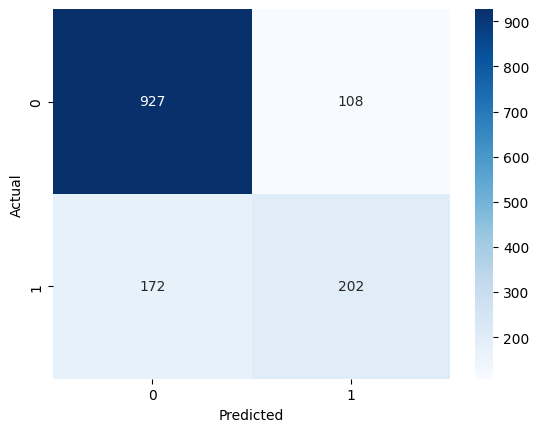

In [53]:
cm = confusion_matrix(results['y_test'], results['y_test_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues') # 'd' avoids scientific notation
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

After introducing early-tenure indicator variables (≤6 months and ≤12 months), the model showed a small improvement in ranking performance, with ROC-AUC increasing slightly from 0.846 to 0.852. However, recall decreased marginally at the default classification threshold, indicating that the additional flags did not meaningfully improve the model's ability to identify churners. Because the continuous tenure feature already captures much of this information, the added indicators were considered redundant and removed in favor of a more compact representation.

In [54]:
new_df = new_df.drop(['tenure_le_6', 'tenure_le_12'], axis=1)

---

We know that Churn risk declines rapidly during the early stages of a customer's lifecycle, and stabilizes as tenure increases. To  capture this behavior we will now apply log transformation on the `Tenure Months` feature. The log transformation expands variation among early-tenure customers while compressing the difference among long-tenure customers, enabling the model to better represent the nonlinear relationship between tenure and churn risk

In [55]:
new_df['log_tenure'] = np.log1p(new_df['Tenure Months'])

In [56]:
new_df = new_df.drop(['Tenure Months'], axis=1)

Now we will remove `Tenure Months` from our features as keeping both of these features would introduce strong correlation between the two, and redundant information, which can lead to multicollinearity and unstable coefficient estimates in linear models

In [57]:
results = run_model_experiment(new_df)

C:\Users\alina\AppData\Local\Temp\ipykernel_36264\3915392292.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(['object']).columns.tolist()


Evaluating Training results

In [58]:
print(classification_report(results['y_train'], results['y_train_pred']))
print(f"ROC AUC Score: {results['train_roc_auc']}")

              precision    recall  f1-score   support

           0       0.86      0.91      0.88      4139
           1       0.69      0.57      0.63      1495

    accuracy                           0.82      5634
   macro avg       0.77      0.74      0.75      5634
weighted avg       0.81      0.82      0.81      5634

ROC AUC Score: 0.8661384772144565


Evaluating Test results

In [59]:
print(results['test_report'])
print(f"ROC AUC Score: {results['test_roc_auc']}")

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

ROC AUC Score: 0.8544627864320958


We see that the ability of our model to rank the classes increased slightly from ~ 0.847 to ~ 0.854, and our recall only decreased from 0.57 to 0.56, which is acceptable, since our decision will not be based on the default decision threshold of 0.5, as we will tune it to increase recall, so we will keep this feature as it allows to capture tenure behavior more accurately

Let us also check how our model with perform with this added feature after threshold is tuned, and the class weights are balanced

Let us create one function that we can use for experimenting with tuning thresholds, moving forward

In [60]:
def tune_threshold(results, min_precision=0.40):
    X_tr, X_val, y_tr, y_val = train_test_split(
        results['X_train'],
        results['y_train'],
        test_size=0.25,
        random_state=42,
        stratify=results['y_train']
    )

    pipe = results['pipe']
    pipe.fit(X_tr, y_tr)

    y_val_probs = pipe.predict_proba(X_val)[:, 1]
    thresholds = np.linspace(0.05, 0.95, 19)

    best = None
    for t in thresholds:
        y_val_pred = (y_val_probs >= t).astype(int)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_val, y_val_pred, average='binary', zero_division=0
        )

        if precision >= min_precision:
            if best is None or recall > best['recall']:
                best = {
                    'threshold': t,
                    'precision': precision,
                    'recall': recall,
                    'f1': f1
                }

    # refit on full training set
    pipe.fit(results['X_train'], results['y_train'])

    y_test_probs = pipe.predict_proba(results['X_test'])[:, 1]
    y_test_pred = (y_test_probs >= best['threshold']).astype(int)

    return {
        'pipe': pipe,
        'best_threshold': best,
        'test_report': classification_report(results['y_test'], y_test_pred, output_dict=True),
        'test_confusion_matrix': confusion_matrix(results['y_test'], y_test_pred),
        'test_roc_auc': roc_auc_score(results['y_test'], y_test_probs),
        'y_test': y_test,
        'y_test_pred': y_test_pred,
        'y_test_probs': y_test_probs
    }

In [61]:
balanced_results = run_model_experiment(new_df, class_weight='balanced')
tuned_results = tune_threshold(balanced_results)

C:\Users\alina\AppData\Local\Temp\ipykernel_36264\3915392292.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(['object']).columns.tolist()


In [62]:
print(tuned_results['test_report']['1'])
print(f"ROC AUC Score: {tuned_results['test_roc_auc']}")

{'precision': 0.4074492099322799, 'recall': 0.9652406417112299, 'f1-score': 0.573015873015873, 'support': 374.0}
ROC AUC Score: 0.8546978738794597


Let us create a function to display the confusion matrix

In [63]:
def display_confusion_matrix(results):
    cm = confusion_matrix(results['y_test'], results['y_test_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues') # 'd' avoids scientific notation
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

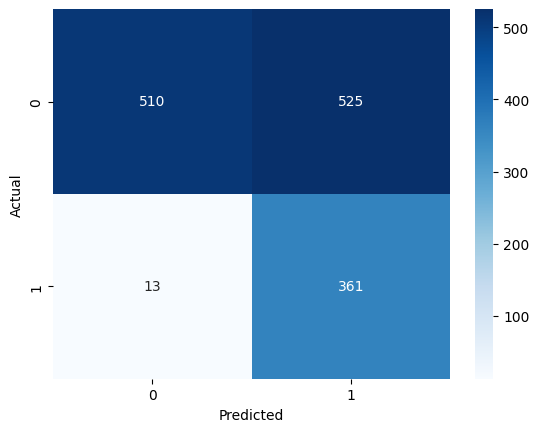

In [64]:
display_confusion_matrix(tuned_results)

After threshold tuning, the model achieves a churn recall of 97%, meaning nearly all churners are successfully identified. This comes at the cost of lower precision (41%), resulting in a higher number of false positives. However, in a churn prevention scenario this trade-off is acceptable because the business objective prioritizes identifying potential churners over minimizing false alarms. The ROC-AUC score of 0.855 indicates that the model maintains strong ranking ability despite the aggressive threshold.

After introducing the `log_tenure` transformation and applying threshold tuning alongside class balancing, the model achieved an ROC-AUC score of approximately 0.855. This indicates that the model has strong ranking capability, meaning it is effective at distinguishing between customers who are likely to churn and those who are not.

With the tuned threshold, the model achieves a recall of approximately 0.97, meaning that it correctly identifies 97% of customers who eventually churn. From a business perspective, this is particularly important in a service-based industry such as telecommunications, where the primary goal is to identify at-risk customers early so retention strategies can be applied.

Given the strong ROC-AUC performance and the high recall achieved, the current model already satisfies the primary objective of this project. Further feature engineering at this stage is unlikely to produce substantial improvements and may introduce unnecessary complexity or noise into the model.

Therefore, we conclude the feature engineering phase here and proceed with model comparison and further evaluation.

---

# 4. Model Selection

For experimentation purposes, we will now train two ensemble models to see if we get any significant increase in ROC AUC Score

In [65]:
models = {
    "Model": ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'ROC AUC': [],
    'Recall': [],
    'Precision': [],
    'F1 Score': [],
    'Threshold': []
}

In [66]:
modelList = [LogisticRegression, RandomForestClassifier, XGBClassifier]

In [67]:
for model in modelList:
    if model != XGBClassifier:
        results = run_model_experiment(new_df, model=model, class_weight='balanced')
        tuned_results = tune_threshold(results)
        report = tuned_results['test_report']
        models['ROC AUC'].append(tuned_results['test_roc_auc'])
        models['Recall'].append(report['1']['recall'])
        models['Precision'].append(report['1']['precision'])
        models['F1 Score'].append(report['1']['f1-score'])
        models['Threshold'].append(tuned_results['best_threshold']['threshold'])
    else:
        results = run_model_experiment(new_df, model=model)
        tuned_results = tune_threshold(results)
        report = tuned_results['test_report']
        models['ROC AUC'].append(tuned_results['test_roc_auc'])
        models['Recall'].append(report['1']['recall'])
        models['Precision'].append(report['1']['precision'])
        models['F1 Score'].append(report['1']['f1-score'])
        models['Threshold'].append(tuned_results['best_threshold']['threshold'])
        

C:\Users\alina\AppData\Local\Temp\ipykernel_36264\3915392292.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(['object']).columns.tolist()
C:\Users\alina\AppData\Local\Temp\ipykernel_36264\3915392292.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/doc

In [68]:
comparison_df = pd.DataFrame(models)
comparison_df

,Model,ROC AUC,Recall,Precision,F1 Score,Threshold
0,Logistic Regression,0.854698,0.965241,0.407449,0.573016,0.20
1,Random Forest,0.826664,0.887701,0.443258,0.591273,0.15
2,XGBoost,0.834480,0.917112,0.409308,0.566007,0.05


After comparing multiple models, Logistic Regression demonstrates the strongest overall performance for this problem. It achieves the highest ROC-AUC score (`~0.85`), outperforming Random Forest (`~0.83`) and XGBoost (`~0.83`).

In addition, Logistic Regression provides the highest recall for churners after threshold tuning (`~0.97`), while Random Forest and XGBoost achieve lower recall (`~0.90–0.92`).

Since the primary business objective is to identify as many churn-risk customers as possible, recall is the most important metric. Logistic Regression therefore provides the best balance between ranking ability (ROC-AUC) and churn detection (recall).

Another advantage of Logistic Regression is interpretability, which allows the business to understand which factors contribute most strongly to churn.

Based on these results, Logistic Regression is selected as the final model for this project.

---

# 5. Model Evaluation

In [69]:
final_model = run_model_experiment(new_df, model=LogisticRegression, class_weight='balanced')
final_results = tune_threshold(final_model)

C:\Users\alina\AppData\Local\Temp\ipykernel_36264\3915392292.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(['object']).columns.tolist()


### ROC AUC Score

In [70]:
print(f"ROC AUC Score: {roc_auc_score(final_results['y_test'], final_results['y_test_probs'])}")

ROC AUC Score: 0.8546978738794597


The model has ROC AUC Scorce of `~0.85`, this means that our model has very strong ability to distinguish between classes across all thresholds.

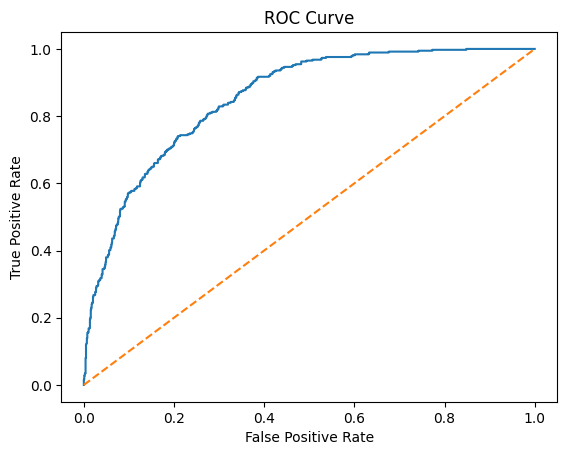

In [71]:
fpr, tpr, thresholds = roc_curve(final_results['y_test'], final_results['y_test_probs'])

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

### Confusion Matrix

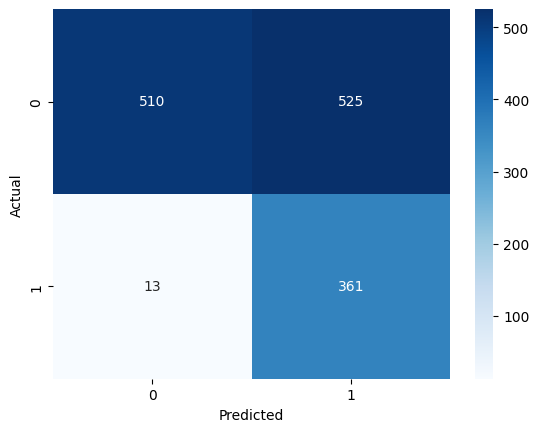

In [72]:
display_confusion_matrix(final_results)

### Classification Report

In [73]:
print(classification_report(final_results['y_test'], final_results['y_test_pred']))

              precision    recall  f1-score   support

           0       0.98      0.49      0.65      1035
           1       0.41      0.97      0.57       374

    accuracy                           0.62      1409
   macro avg       0.69      0.73      0.61      1409
weighted avg       0.82      0.62      0.63      1409



The test dataset contains 374 churners and 1035 non-churners. Despite this class imbalance, the model successfully identifies approximately 97% of churners, demonstrating strong performance on the minority class.

Although precision decreases to approximately 41%, this means that roughly 59% of flagged customers would not have churned. However, in a churn prevention strategy this cost is acceptable, as retention campaigns are typically inexpensive compared to the revenue lost from churn.

If the company evaluates 1000 customers and the churn rate remains ~26%, approximately 260 customers would churn. With a recall of 97%, the model would successfully identify roughly 252 churners, enabling the company to proactively target these customers with retention offers.

### Threshold Strategy

In [74]:
print(f"Best Threshold Value: {final_results['best_threshold']['threshold']}")

Best Threshold Value: 0.2


The classification threshold was lowered to 0.2 to maximize recall.
This allows the company to detect nearly all churners, accepting additional false positives as a business tradeoff.

### Precision Recall Curve

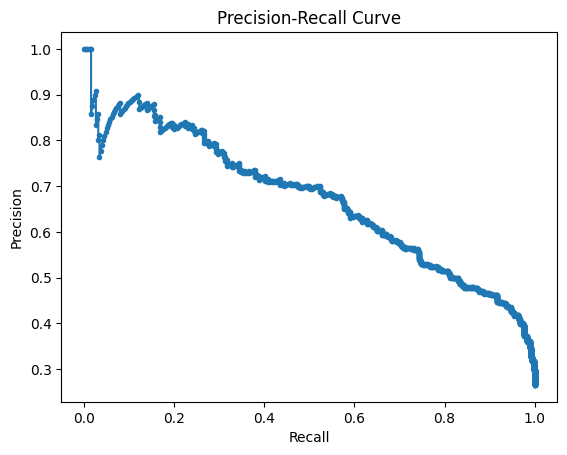

In [75]:
precision, recall, thresholds = precision_recall_curve(final_results['y_test'], final_results['y_test_probs'])
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

### Feature Importance

In [76]:
feature_names = final_results['pipe'].named_steps['preprocessor'].get_feature_names_out()
coefficients = final_results['pipe'].named_steps['model'].coef_[0]
intercept = final_results['pipe'].named_steps['model'].intercept_
importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending=False)

In [77]:
print(intercept)
importance['Odds_ratio'] = np.exp(importance['Coefficient'])
importance

[-0.5223675]


,Feature,Coefficient,Odds_ratio
8,cat__Internet Service_Fiber optic,1.018970,2.770339
7,cat__Multiple Lines_Yes,0.388348,1.474543
15,cat__Streaming Movies_Yes,0.383024,1.466714
14,cat__Streaming TV_Yes,0.369162,1.446522
20,cat__Payment Method_Electronic check,0.355230,1.426509
18,cat__Paperless Billing_Yes,0.327350,1.387287
4,cat__Partner_Yes,0.306099,1.358117
3,cat__Senior Citizen_Yes,0.033700,1.034274
12,cat__Device Protection_Yes,0.033588,1.034158
2,cat__Gender_Male,0.020786,1.021003


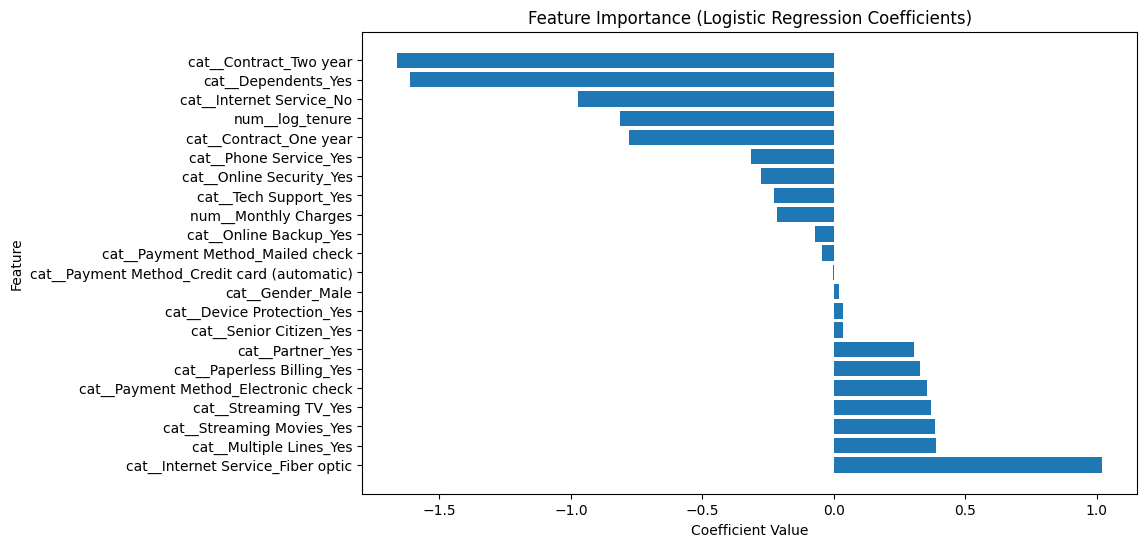

In [78]:
plt.figure(figsize=(10,6))
plt.barh(importance['Feature'], importance['Coefficient'])
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

### Key Drivers of Customer Churn

Analysis of the Logistic Regression coefficients reveals several important drivers of churn behavior.

The strongest factor increasing churn risk is `fiber optic internet service`, suggesting that customers using higher-tier internet services may have higher service expectations or may be more sensitive to pricing and performance issues.

Customers using `electronic check payments` also show higher churn probability compared to those using automatic payment methods. This may indicate lower billing commitment or less stable payment behavior.

Customers who heavily use `streaming services show moderately higher churn risk`, which may indicate higher service expectations or sensitivity to network performance.

### Factors Reducing Churn

Several features significantly reduce churn probability.

The strongest retention factor is `contract length`, with customers on `two-year contracts` showing the lowest churn risk.

Customer `tenure` also plays a major role. As tenure increases, churn probability decreases significantly, confirming that long-term customers are more stable.

Customers with `dependents` also exhibit lower churn probability, suggesting that households with shared service usage are less likely to switch providers.

---

### Key Findings

Several important insights emerged from the analysis:

- Customers on month-to-month contracts exhibit significantly higher churn risk.

- Fiber optic users show elevated churn rates, likely due to higher expectations or pricing sensitivity.
  
- Early-tenure customers are particularly vulnerable to churn.

- Automatic payment methods correlate with lower churn.

- Adoption of additional services such as technical support and security increases retention.

These findings highlight both behavioral and service-related drivers of customer churn.

# 6. Business Recommendations

Based on the model results and feature importance analysis, several factors appear to influence customer churn. These insights can help the company design strategies to reduce churn.

**Contract Type**

Customers with month-to-month contracts show much higher churn rates compared to customers with one-year or two-year contracts. Encouraging customers to move to longer contracts through small discounts or bundled offers may help reduce churn.

**Fiber Optic Customers**

Customers using fiber optic internet show higher churn probability. This may indicate higher expectations from these customers. Monitoring service quality and offering targeted retention offers to fiber customers could help improve retention.

**Payment Method**

Customers paying through electronic check have higher churn rates compared to customers using automatic payments. Encouraging customers to switch to automatic payment methods such as credit card or bank transfer may improve retention.

**Early Tenure Customers**

Customers with shorter tenure are more likely to churn. This suggests that the first few months are critical for retention. Improving onboarding and early customer engagement may help reduce churn during this period.

**Additional Services**

Customers who subscribe to additional services such as tech support, online security, or device protection tend to churn less. Promoting these services as part of bundled packages could increase customer engagement and reduce churn.

---

# 7. Customer Segmentation

We will now towards Customer Segmentation, the goal here is to find out the type of customers we have, based on their behavior and usage values

In [79]:
segment_df = new_df.copy()
segment_df['Total Charges'] = df['Total Charges']
segment_df['CLTV'] = df['CLTV']
segment_df['Tenure Months'] = df['Tenure Months']
segment_df = segment_df.drop(['Gender', 'log_tenure', 'Churn Value'], axis=1)

In [80]:
segment_df.columns

Index(['Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'CLTV', 'Tenure Months'],
      dtype='str')

In [81]:
categorical_features = segment_df.select_dtypes(['object']).columns.tolist()
numeric_features = segment_df.select_dtypes(['int', 'float']).columns.tolist()

C:\Users\alina\AppData\Local\Temp\ipykernel_36264\1064000493.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = segment_df.select_dtypes(['object']).columns.tolist()


In [82]:
segmentation_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ]
)

In [83]:
X_segment = segmentation_preprocessor.fit_transform(segment_df)
X_segment.shape

(7043, 23)

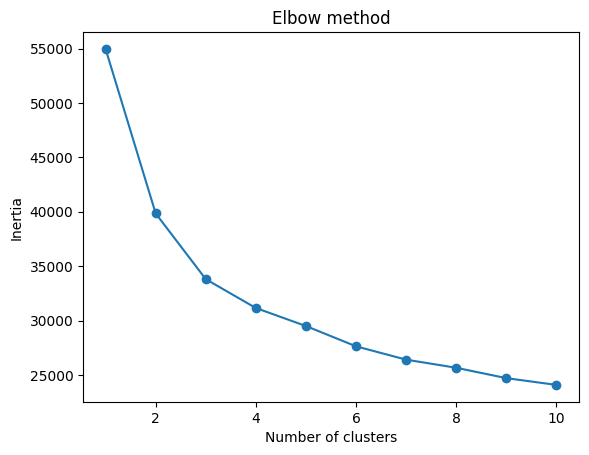

In [84]:
inertias = []
silhouette_scores = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_segment)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

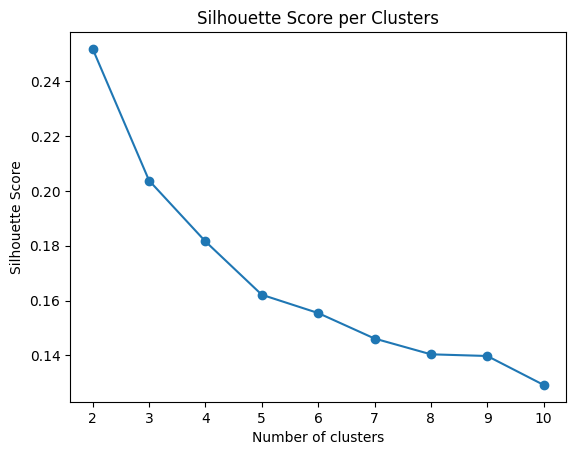

In [85]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_segment)
    silhouette_scores.append(silhouette_score(X_segment, labels))

# Plot starting from 2 clusters to match our data
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Score per Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score') 
plt.show()

Based on the above plots, we choose `k = 3` for clustering. While k = 2 has the highest silhouette score, using only two clusters would oversimplify customer segmentation. Choosing k = 3 provides a better balance between interpretability and cluster quality, as the inertia curve shows diminishing returns beyond this point while the silhouette score remains acceptable.

In [86]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_segment)

segment_df['Cluster'] = labels

In [87]:
cluster_summary = segment_df.groupby('Cluster')[numeric_features].mean()
cluster_summary

,Monthly Charges,Total Charges,CLTV,Tenure Months
Cluster,,,,
0,27.931662,716.928304,4434.773752,26.756960
1,76.860244,1270.189813,3799.249908,16.179771
2,89.180517,5320.102390,5148.827620,59.685176


- Cluster 0 consists of low-spending customers with moderate tenure, resulting in moderate lifetime value.
- Cluster 1 includes high-spending customers with short tenure, leading to lower overall lifetime value.
- Cluster 2 represents high-spending customers with long tenure and the highest lifetime value, making them the most valuable segment.

In [88]:
categoricals_profiles = {}
for feature in categorical_features:
    categoricals_profiles[feature] = pd.crosstab(segment_df['Cluster'], segment_df[feature], normalize='index')


In [89]:
from IPython.display import display

for feature, table in categoricals_profiles.items():
    print(f"\n===== {feature} =====")
    display(table)


===== Senior Citizen =====


Senior Citizen,No,Yes
Cluster,,
0,0.944764,0.055236
1,0.780362,0.219638
2,0.796234,0.203766



===== Partner =====


Partner,No,Yes
Cluster,,
0,0.547945,0.452055
1,0.655223,0.344777
2,0.302269,0.697731



===== Dependents =====


Dependents,No,Yes
Cluster,,
0,0.661511,0.338489
1,0.876338,0.123662
2,0.746016,0.253984



===== Phone Service =====


Phone Service,No,Yes
Cluster,,
0,0.162174,0.837826
1,0.056848,0.943152
2,0.077740,0.922260



===== Multiple Lines =====


Multiple Lines,No,Yes
Cluster,,
0,0.826779,0.173221
1,0.574382,0.425618
2,0.311444,0.688556



===== Internet Service =====


Internet Service,DSL,Fiber optic,No
Cluster,,,
0,0.325674,0.000000,0.674326
1,0.325951,0.674049,0.000000
2,0.386770,0.613230,0.000000



===== Online Security =====


Online Security,No,Yes
Cluster,,
0,0.897039,0.102961
1,0.771872,0.228128
2,0.436021,0.563979



===== Online Backup =====


Online Backup,No,Yes
Cluster,,
0,0.924437,0.075563
1,0.695829,0.304171
2,0.307581,0.692419



===== Device Protection =====


Device Protection,No,Yes
Cluster,,
0,0.940787,0.059213
1,0.682540,0.317460
2,0.310478,0.689522



===== Tech Support =====


Tech Support,No,Yes
Cluster,,
0,0.912064,0.087936
1,0.760059,0.239941
2,0.422984,0.577016



===== Streaming TV =====


Streaming TV,No,Yes
Cluster,,
0,0.969068,0.030932
1,0.572905,0.427095
2,0.285369,0.714631



===== Streaming Movies =====


Streaming Movies,No,Yes
Cluster,,
0,0.972603,0.027397
1,0.566630,0.433370
2,0.277644,0.722356



===== Contract =====


Contract,Month-to-month,One year,Two year
Cluster,,,
0,0.475475,0.220062,0.304463
1,0.856774,0.117386,0.025840
2,0.230806,0.317238,0.451956



===== Paperless Billing =====


Paperless Billing,No,Yes
Cluster,,
0,0.657092,0.342908
1,0.270949,0.729051
2,0.314341,0.685659



===== Payment Method =====


Payment Method,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Cluster,,,,
0,0.198409,0.210340,0.129032,0.462218
1,0.155408,0.144334,0.548911,0.151347
2,0.325447,0.316272,0.282955,0.075326


Using K-Means clustering with k=3, we identified three distinct customer groups based on service usage, spending patterns, tenure, and billing characteristics.

**Cluster 0 — Budget Minimal Users**
This segment consists of low-spending customers with limited service usage. Many customers in this group either have no internet service or use basic DSL only, and very few subscribe to additional services. Monthly charges and total revenue from this group are low, although their tenure is moderate. These customers represent low-value accounts with minimal engagement.

**Cluster 1 — Premium Bundled Users**
Customers in this segment have high service adoption and typically subscribe to multiple add-on features such as streaming services, online security, and backup options. Fiber optic internet is common in this group, and monthly charges are significantly higher than Cluster 0. These customers generate strong recurring revenue and show high engagement with the company’s offerings.

**Cluster 2 — High-Value but Volatile Customers**
This group contains the highest-value customers in terms of monthly charges, total charges, tenure, and lifetime value. However, most of these customers are on month-to-month contracts and rely heavily on electronic check payments, indicating lower commitment despite high spending. This makes them potentially at risk of churn compared to long-term contract customers.

Overall, the segmentation reveals meaningful differences in customer value, service adoption, and retention risk, which can help guide targeted marketing, pricing, and retention strategies.

---

# 8. PCA

We will now use PCA for dimensionality reduction so we can easily visualize our clusters

In [90]:
X_segment = segmentation_preprocessor.fit_transform(segment_df)
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_segment)

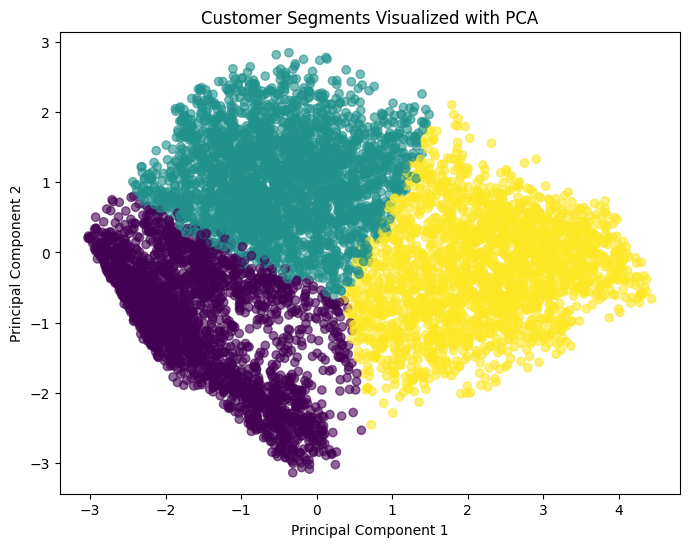

In [91]:
plt.figure(figsize=(8,6))
plt.scatter(
    principal_components[:, 0],
    principal_components[:, 1],
    c=segment_df['Cluster'],
    alpha=0.6
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments Visualized with PCA")
plt.show()

In [92]:
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.37663304 0.16836297]
Total explained variance: 0.5449960103500417


To validate the clustering results, Principal Component Analysis (PCA) was applied to reduce the high-dimensional feature space to two dimensions for visualization. The first two principal components explain approximately 54.5% of the total variance in the data, indicating that the projection retains a substantial amount of information.

The resulting scatter plot shows three distinct clusters with clear separation, particularly for one highly compact segment, while some overlap exists between others. This suggests that the KMeans algorithm successfully identified meaningful customer groupings rather than arbitrary partitions. The overlap observed reflects natural similarities among certain customers, which is expected in real-world behavioral data.

---

## Model Limitations

While the model demonstrates strong performance, several limitations should be noted:

- The dataset represents a fictional telco company and may not capture all real-world complexities.

- External factors such as competitor actions, service outages, or macroeconomic conditions are not included.

- Clustering results depend on selected features and may vary with different inputs.

- The model is trained on historical data and may require retraining as customer behavior evolves.

Addressing these limitations would further improve real-world applicability.

---

## Business Impact

The system enables proactive retention strategies by identifying customers at high risk of churn before they leave. Early intervention can significantly reduce revenue loss.

By combining churn prediction with customer segmentation, the company can:

- Prioritize retention efforts toward high-value customers

- Tailor marketing campaigns to specific segments

- Optimize pricing and contract strategies

- Improve customer onboarding experiences

Overall, the solution transforms reactive churn management into a proactive, data-driven process.

---

## System Workflow

The final Customer Intelligence System operates as follows:

1. A new customer's data is provided as input.
2. The preprocessing pipeline transforms the raw features using the same transformations applied during training.
3. The churn prediction model estimates the probability that the customer will churn.
4. The clustering model assigns the customer to a behavioral segment.
5. The system outputs both:
   - Churn risk score
   - Customer segment label

This combined output allows businesses to identify not only who is likely to churn, but also what type of customer they are, enabling targeted retention strategies.

---

## Saving Models for Production Pipeline

In [93]:
import joblib

In [94]:
churn_pipe = final_results['pipe']
segmentation_preprocessor = segmentation_preprocessor
segmentation_model =  kmeans
threshold_config = {
    'churn_threshold' : final_results['best_threshold']['threshold']
}

In [95]:
joblib.dump(churn_pipe, 'Churn_Pipeline')
joblib.dump(segmentation_preprocessor, 'Segmentation_Preprocessor')
joblib.dump(segmentation_model, 'Segmentation_Model')
joblib.dump(threshold_config, 'Threshold_Config')

['Threshold_Config']

In [96]:
loaded_churn_pipe = joblib.load('Churn_Pipeline')
loaded_segmentation_preprocessor = joblib.load('Segmentation_Preprocessor')
loaded_segmentation_model = joblib.load('Segmentation_Model')
loaded_threshold_config = joblib.load('Threshold_Config')

In [97]:
sample_churn_input = new_df.drop(columns=['Churn Value']).iloc[[0]]
sample_segmentation_input = segment_df.drop(columns=['Cluster']).iloc[[0]]

In [98]:
churn_prob = loaded_churn_pipe.predict_proba(sample_churn_input)[:, 1][0]
threshold = loaded_threshold_config['churn_threshold']
churn_label = int(churn_prob >= threshold)

In [99]:
print("Churn probability:", churn_prob)
print("Threshold:", threshold)
print("Predicted churn label:", churn_label)

Churn probability: 0.6373891729820784
Threshold: 0.2
Predicted churn label: 1


In [100]:
sample_segment_transformed = loaded_segmentation_preprocessor.transform(sample_segmentation_input)
segment_label = loaded_segmentation_model.predict(sample_segment_transformed)[0]
print("Predicted segment:", segment_label)

Predicted segment: 1


In [101]:
if churn_prob >= 0.75:
    risk_level = "High"
elif churn_prob >= threshold:
    risk_level = "Medium"
else:
    risk_level = "Low"

segment_map = {
    0: "Budget Minimal Users",
    1: "Premium Bundled Users",
    2: "High-Value but Volatile Customers"
}

result = {
    "churn_probability": float(churn_prob),
    "churn_label": int(churn_label),
    "risk_level": risk_level,
    "segment": int(segment_label),
    "segment_name": segment_map[int(segment_label)]
}

result

{'churn_probability': 0.6373891729820784,
 'churn_label': 1,
 'risk_level': 'Medium',
 'segment': 1,
 'segment_name': 'Premium Bundled Users'}

In [102]:
def analyze_customer(churn_input_df, segmentation_input_df):
    loaded_churn_pipe = joblib.load('Churn_Pipeline')
    loaded_segmentation_preprocessor = joblib.load('Segmentation_Preprocessor')
    loaded_segmentation_model = joblib.load('Segmentation_Model')
    loaded_threshold_config = joblib.load('Threshold_Config')

    churn_prob = loaded_churn_pipe.predict_proba(churn_input_df)[:, 1][0]
    threshold = loaded_threshold_config['churn_threshold']
    churn_label = int(churn_prob >= threshold)

    segment_transformed = loaded_segmentation_preprocessor.transform(segmentation_input_df)
    segment_label = loaded_segmentation_model.predict(segment_transformed)[0]

    if churn_prob >= 0.75:
        risk_level = "High"
    elif churn_prob >= threshold:
        risk_level = "Medium"
    else:
        risk_level = "Low"
    
    segment_map = {
        0: "Budget Minimal Users",
        1: "Premium Bundled Users",
        2: "High-Value but Volatile Customers"
    }
    
    result = {
        "churn_probability": float(churn_prob),
        "churn_label": int(churn_label),
        "risk_level": risk_level,
        "segment": int(segment_label),
        "segment_name": segment_map[int(segment_label)]
    }
    
    return result

In [103]:
analyze_customer(sample_churn_input, sample_segmentation_input)

{'churn_probability': 0.6373891729820784,
 'churn_label': 1,
 'risk_level': 'Medium',
 'segment': 1,
 'segment_name': 'Premium Bundled Users'}